# 10 — External Domain-Shift Evaluation on PlantDoc

This notebook evaluates the final Main19 EfficientNet-B0 model on the PlantDoc test split.

## Evaluation protocol

- Source training domain: Main19 PlantVillage subset.
- External target domain: PlantDoc test split.
- Model: `best_efficientnet_b0_main19.pt`.
- Labels: `class_to_index_main19.json`.
- Evaluation type: zero-shot external-domain evaluation.
- PlantDoc `train/` images are not used.
- Only disease/crop labels included in the Main19 project label set are used in supervised metrics.

## Goal

Measure how model performance changes when moving from controlled PlantVillage images to more realistic PlantDoc images with background clutter, variable illumination, occlusion, multiple leaves, camera-angle variation, and symptom variation.

A lower external score is expected evidence of domain shift. It is not necessarily a model-loading error.

In [1]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMAGE_SIZE = 224
BATCH_SIZE = 32 if DEVICE.type == "cuda" else 8
NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

print("Device:", DEVICE)
print("Torch version:", torch.__version__)

Device: cuda
Torch version: 2.10.0+cu128


In [2]:
INPUT_ROOT = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")

# User-provided PlantDoc dataset path.
PLANTDOC_ROOT = Path(
    "/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset"
)

# Use only the external PlantDoc test split.
EVAL_ROOT = PLANTDOC_ROOT / "test"

RESULTS_DIR = (
    WORKING_ROOT
    / "results"
    / "notebook_10_external_domain_shift_plantdoc"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PlantDoc root:", PLANTDOC_ROOT)
print("PlantDoc root exists:", PLANTDOC_ROOT.exists())
print("PlantDoc test root:", EVAL_ROOT)
print("PlantDoc test root exists:", EVAL_ROOT.exists())
print("Results directory:", RESULTS_DIR)

PlantDoc root: /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset
PlantDoc root exists: True
PlantDoc test root: /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test
PlantDoc test root exists: True
Results directory: /kaggle/working/results/notebook_10_external_domain_shift_plantdoc


In [3]:
assert PLANTDOC_ROOT.exists(), (
    f"PlantDoc root was not found:\n{PLANTDOC_ROOT}\n\n"
    "Check whether the dataset is attached in Kaggle Input."
)

assert EVAL_ROOT.exists(), (
    f"PlantDoc test directory was not found:\n{EVAL_ROOT}\n\n"
    "Expected folder structure:\n"
    "plantdoc-dataset/test/<class_folder>/<image>.jpg"
)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}

def image_files_under(folder_path):
    return sorted(
        file_path
        for file_path in folder_path.rglob("*")
        if file_path.is_file()
        and file_path.suffix.lower() in IMAGE_EXTENSIONS
    )

test_class_dirs = sorted(
    folder
    for folder in EVAL_ROOT.iterdir()
    if folder.is_dir()
)

plantdoc_test_inventory = pd.DataFrame(
    {
        "plantdoc_folder": [
            folder.name
            for folder in test_class_dirs
        ],
        "image_count": [
            len(image_files_under(folder))
            for folder in test_class_dirs
        ],
    }
).sort_values("plantdoc_folder").reset_index(drop=True)

print(
    "Number of PlantDoc test folders:",
    len(plantdoc_test_inventory),
)

print(
    "Total PlantDoc test images:",
    f"{plantdoc_test_inventory['image_count'].sum():,}",
)

display(plantdoc_test_inventory)

plantdoc_test_inventory.to_csv(
    RESULTS_DIR / "table_01_plantdoc_test_inventory.csv",
    index=False,
)

Number of PlantDoc test folders: 27
Total PlantDoc test images: 252


,plantdoc_folder,image_count
0,Apple_Scab_Leaf,10
1,Apple_leaf,9
2,Apple_rust_leaf,10
3,Bell_pepper_leaf,8
4,Bell_pepper_leaf_spot,9
5,Blueberry_leaf,11
6,Cherry_leaf,10
7,Corn_Gray_leaf_spot,4
8,Corn_leaf_blight,12
9,Corn_rust_leaf,10


In [4]:
def find_files_by_name(search_roots, filename):
    discovered_files = []

    for root in search_roots:
        if root.exists():
            discovered_files.extend(
                path
                for path in root.rglob(filename)
                if path.is_file()
            )

    return sorted(set(discovered_files))

SEARCH_ROOTS = [
    INPUT_ROOT,
    WORKING_ROOT,
]

checkpoint_candidates = find_files_by_name(
    SEARCH_ROOTS,
    "best_efficientnet_b0_main19.pt",
)

class_mapping_candidates = find_files_by_name(
    SEARCH_ROOTS,
    "class_to_index_main19.json",
)

index_mapping_candidates = find_files_by_name(
    SEARCH_ROOTS,
    "index_to_class_main19.json",
)

temperature_metrics_candidates = find_files_by_name(
    SEARCH_ROOTS,
    "proposed_model_temperature_scaling_metrics.csv",
)

training_config_candidates = find_files_by_name(
    SEARCH_ROOTS,
    "training_config.json",
)

print("Checkpoint candidates:")
for path in checkpoint_candidates:
    print(" -", path)

print("\nClass-to-index candidates:")
for path in class_mapping_candidates:
    print(" -", path)

print("\nIndex-to-class candidates:")
for path in index_mapping_candidates:
    print(" -", path)

print("\nTemperature metrics candidates:")
for path in temperature_metrics_candidates:
    print(" -", path)

print("\nTraining config candidates:")
for path in training_config_candidates:
    print(" -", path)

if not checkpoint_candidates:
    raise FileNotFoundError(
        "Could not find best_efficientnet_b0_main19.pt.\n\n"
        "Attach the Kaggle dataset containing your Notebook 03 output."
    )

if not class_mapping_candidates:
    raise FileNotFoundError(
        "Could not find class_to_index_main19.json.\n\n"
        "Attach the Kaggle dataset containing split_outputs/metadata."
    )

CHECKPOINT_PATH = checkpoint_candidates[0]
CLASS_MAPPING_PATH = class_mapping_candidates[0]

INDEX_MAPPING_PATH = (
    index_mapping_candidates[0]
    if index_mapping_candidates
    else None
)

TEMPERATURE_METRICS_PATH = (
    temperature_metrics_candidates[0]
    if temperature_metrics_candidates
    else None
)

TRAINING_CONFIG_PATH = (
    training_config_candidates[0]
    if training_config_candidates
    else None
)

print("\nSelected files")
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("CLASS_MAPPING_PATH:", CLASS_MAPPING_PATH)
print("INDEX_MAPPING_PATH:", INDEX_MAPPING_PATH)
print("TEMPERATURE_METRICS_PATH:", TEMPERATURE_METRICS_PATH)
print("TRAINING_CONFIG_PATH:", TRAINING_CONFIG_PATH)

Checkpoint candidates:
 - /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/best_efficientnet_b0_main19.pt

Class-to-index candidates:
 - /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/class_to_index_main19.json

Index-to-class candidates:
 - /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/index_to_class_main19.json

Temperature metrics candidates:
 - /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb_06/nb_06/proposed_model_temperature_scaling_metrics.csv

Training config candidates:
 - /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/training_config.json
 - /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb_05/nb_05/training_config.json

Selected files
CHECKPOINT_PATH: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/best_efficientnet_b0_main19.pt
CLASS_MAPPING_PATH: /kaggle/input/datasets/kataku

In [5]:
with open(CLASS_MAPPING_PATH, "r", encoding="utf-8") as file:
    raw_class_mapping = json.load(file)

# Expected format:
# {
#   "corn__common_rust": 0,
#   "tomato__early_blight": 1,
#   ...
# }
#
# This code also safely handles an accidental reversed mapping.

if all(str(key).isdigit() for key in raw_class_mapping.keys()):
    idx_to_class = {
        int(index): str(class_name)
        for index, class_name in raw_class_mapping.items()
    }

    class_to_idx = {
        class_name: index
        for index, class_name in idx_to_class.items()
    }

else:
    class_to_idx = {
        str(class_name): int(index)
        for class_name, index in raw_class_mapping.items()
    }

    idx_to_class = {
        index: class_name
        for class_name, index in class_to_idx.items()
    }

NUM_CLASSES = len(class_to_idx)

print("Number of Main19 model classes:", NUM_CLASSES)
print("\nMain19 class labels:")

model_classes_df = pd.DataFrame(
    {
        "class_index": sorted(idx_to_class.keys()),
        "class_label": [
            idx_to_class[index]
            for index in sorted(idx_to_class.keys())
        ],
    }
)

display(model_classes_df)

model_classes_df.to_csv(
    RESULTS_DIR / "table_02_main19_model_class_mapping.csv",
    index=False,
)

assert NUM_CLASSES == 19, (
    f"Expected 19 Main19 classes, but found {NUM_CLASSES}. "
    "Confirm that class_to_index_main19.json was selected."
)

Number of Main19 model classes: 19

Main19 class labels:


,class_index,class_label
0,0,bell_pepper__bacterial_spot
1,1,bell_pepper__healthy
2,2,corn__cercospora_leaf_spot_gray_leaf_spot
3,3,corn__common_rust
4,4,corn__healthy
5,5,corn__northern_leaf_blight
6,6,potato__early_blight
7,7,potato__healthy
8,8,potato__late_blight
9,9,tomato__bacterial_spot


In [6]:
if INDEX_MAPPING_PATH is not None:
    with open(INDEX_MAPPING_PATH, "r", encoding="utf-8") as file:
        raw_index_mapping = json.load(file)

    loaded_idx_to_class = {
        int(index): str(class_name)
        for index, class_name in raw_index_mapping.items()
    }

    mapping_matches = (
        loaded_idx_to_class == idx_to_class
    )

    print("index_to_class_main19.json matches class_to_index_main19.json:")
    print(mapping_matches)

    if not mapping_matches:
        print(
            "\nWarning: The two mapping files do not match exactly. "
            "Use the mapping associated with the selected checkpoint."
        )

else:
    print(
        "No index_to_class_main19.json was found. "
        "Continuing with class_to_index_main19.json."
    )

index_to_class_main19.json matches class_to_index_main19.json:
True


In [7]:
# This mapping includes only labels trained in the Main19 project:
#
# - Corn: healthy, gray leaf spot, common rust, northern leaf blight
# - Bell pepper: healthy, bacterial spot
# - Potato: healthy, early blight, late blight
# - Tomato: healthy, bacterial spot, early blight, late blight,
#   leaf mold, septoria leaf spot, spider mites, target spot,
#   tomato mosaic virus, tomato yellow leaf curl virus
#
# Labels outside the Main19 project are explicitly excluded with None.
#
# IMPORTANT:
# Cell 9 checks every non-None string against class_to_idx.
# If the naming is different, copy the exact class label from Cell 6.

PLANTDOC_TO_MAIN19 = {
    # ----------------------------------------------------------
    # Corn labels used in the Main19 model
    # ----------------------------------------------------------
    "Corn_Gray_leaf_spot": (
        "corn__cercospora_leaf_spot_gray_leaf_spot"
    ),
    "Corn_leaf_blight": "corn__northern_leaf_blight",
    "Corn_rust_leaf": "corn__common_rust",

    # ----------------------------------------------------------
    # Bell pepper labels used in the Main19 model
    # ----------------------------------------------------------
    "Bell_pepper_leaf": "bell_pepper__healthy",
    "Bell_pepper_leaf_spot": "bell_pepper__bacterial_spot",

    # ----------------------------------------------------------
    # Potato labels used in the Main19 model
    # ----------------------------------------------------------
    "Potato_leaf_early_blight": "potato__early_blight",
    "Potato_leaf_late_blight": "potato__late_blight",

    # ----------------------------------------------------------
    # Tomato labels used in the Main19 model
    # ----------------------------------------------------------
    "Tomato_Early_blight_leaf": "tomato__early_blight",
    "Tomato_Septoria_leaf_spot": "tomato__septoria_leaf_spot",
    "Tomato_leaf": "tomato__healthy",
    "Tomato_leaf_bacterial_spot": "tomato__bacterial_spot",
    "Tomato_leaf_late_blight": "tomato__late_blight",
    "Tomato_leaf_mosaic_virus": (
        "tomato__tomato_mosaic_virus"
    ),
    "Tomato_leaf_yellow_virus": (
        "tomato__tomato_yellow_leaf_curl_virus"
    ),
    "Tomato_mold_leaf": "tomato__leaf_mold",
    "Tomato_two_spotted_spider_mites_leaf": (
        "tomato__spider_mites_two_spotted_spider_mite"
    ),

    # ----------------------------------------------------------
    # Excluded PlantDoc folders outside the Main19 project
    # ----------------------------------------------------------
    "Apple_Scab_Leaf": None,
    "Apple_leaf": None,
    "Apple_rust_leaf": None,
    "Blueberry_leaf": None,
    "Cherry_leaf": None,
    "Peach_leaf": None,
    "Raspberry_leaf": None,
    "Soyabean_leaf": None,
    "Squash_Powdery_mildew_leaf": None,
    "Strawberry_leaf": None,
    "grape_leaf": None,
    "grape_leaf_black_rot": None,
}

In [8]:
mapping_audit = plantdoc_test_inventory.copy()

mapping_audit["mapped_main19_label"] = (
    mapping_audit["plantdoc_folder"]
    .map(PLANTDOC_TO_MAIN19)
)

mapping_audit["mapping_status"] = np.select(
    [
        mapping_audit["mapped_main19_label"].isna(),

        mapping_audit["mapped_main19_label"].isin(
            class_to_idx.keys()
        ),
    ],
    [
        "excluded_outside_main19",
        "compatible",
    ],
    default="error_label_not_in_main19_mapping",
)

display(mapping_audit)

missing_labels_df = mapping_audit.loc[
    mapping_audit["mapping_status"]
    == "error_label_not_in_main19_mapping",
    [
        "plantdoc_folder",
        "mapped_main19_label",
    ],
]

if not missing_labels_df.empty:
    print(
        "The following mapping values were not found in "
        "class_to_index_main19.json:"
    )

    display(missing_labels_df)

    print("\nAvailable Main19 labels:")
    print(sorted(class_to_idx.keys()))

    raise ValueError(
        "Correct PLANTDOC_TO_MAIN19 using the exact labels shown "
        "in Cell 6, then rerun Cells 8 and 9."
    )

compatible_mapping = mapping_audit.loc[
    mapping_audit["mapping_status"] == "compatible"
].copy()

excluded_mapping = mapping_audit.loc[
    mapping_audit["mapping_status"]
    == "excluded_outside_main19"
].copy()

print("Compatible PlantDoc folders:", len(compatible_mapping))
print("Excluded PlantDoc folders:", len(excluded_mapping))

print("\nCompatible folders:")
display(compatible_mapping)

print("\nExcluded folders:")
display(excluded_mapping)

mapping_audit.to_csv(
    RESULTS_DIR / "table_03_plantdoc_main19_mapping_audit.csv",
    index=False,
)

,plantdoc_folder,image_count,mapped_main19_label,mapping_status
0,Apple_Scab_Leaf,10,None,excluded_outside_main19
1,Apple_leaf,9,None,excluded_outside_main19
2,Apple_rust_leaf,10,None,excluded_outside_main19
3,Bell_pepper_leaf,8,bell_pepper__healthy,compatible
4,Bell_pepper_leaf_spot,9,bell_pepper__bacterial_spot,compatible
5,Blueberry_leaf,11,None,excluded_outside_main19
6,Cherry_leaf,10,None,excluded_outside_main19
7,Corn_Gray_leaf_spot,4,corn__cercospora_leaf_spot_gray_leaf_spot,compatible
8,Corn_leaf_blight,12,corn__northern_leaf_blight,compatible
9,Corn_rust_leaf,10,corn__common_rust,compatible


Compatible PlantDoc folders: 15
Excluded PlantDoc folders: 12

Compatible folders:


,plantdoc_folder,image_count,mapped_main19_label,mapping_status
3,Bell_pepper_leaf,8,bell_pepper__healthy,compatible
4,Bell_pepper_leaf_spot,9,bell_pepper__bacterial_spot,compatible
7,Corn_Gray_leaf_spot,4,corn__cercospora_leaf_spot_gray_leaf_spot,compatible
8,Corn_leaf_blight,12,corn__northern_leaf_blight,compatible
9,Corn_rust_leaf,10,corn__common_rust,compatible
11,Potato_leaf_early_blight,14,potato__early_blight,compatible
12,Potato_leaf_late_blight,8,potato__late_blight,compatible
17,Tomato_Early_blight_leaf,9,tomato__early_blight,compatible
18,Tomato_Septoria_leaf_spot,12,tomato__septoria_leaf_spot,compatible
19,Tomato_leaf,8,tomato__healthy,compatible



Excluded folders:


,plantdoc_folder,image_count,mapped_main19_label,mapping_status
0,Apple_Scab_Leaf,10,None,excluded_outside_main19
1,Apple_leaf,9,None,excluded_outside_main19
2,Apple_rust_leaf,10,None,excluded_outside_main19
5,Blueberry_leaf,11,None,excluded_outside_main19
6,Cherry_leaf,10,None,excluded_outside_main19
10,Peach_leaf,9,None,excluded_outside_main19
13,Raspberry_leaf,7,None,excluded_outside_main19
14,Soyabean_leaf,8,None,excluded_outside_main19
15,Squash_Powdery_mildew_leaf,6,None,excluded_outside_main19
16,Strawberry_leaf,8,None,excluded_outside_main19


In [9]:
manifest_records = []

for _, row in compatible_mapping.iterrows():
    plantdoc_folder = row["plantdoc_folder"]
    main19_label = row["mapped_main19_label"]

    class_folder_path = EVAL_ROOT / plantdoc_folder

    crop, disease = main19_label.split(
        "__",
        maxsplit=1,
    )

    for image_path in image_files_under(class_folder_path):
        manifest_records.append(
            {
                "image_path": str(image_path),
                "plantdoc_folder": plantdoc_folder,
                "true_label": main19_label,
                "true_index": class_to_idx[main19_label],
                "crop": crop,
                "disease": disease,
            }
        )

external_df = pd.DataFrame(manifest_records)

assert not external_df.empty, (
    "No compatible PlantDoc images were included. "
    "Review the mapping and dataset path."
)

external_class_summary = (
    external_df
    .groupby(
        [
            "plantdoc_folder",
            "true_label",
            "crop",
            "disease",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "images"})
    .sort_values(
        ["crop", "disease"],
        ascending=True,
    )
    .reset_index(drop=True)
)

print(
    "Compatible external PlantDoc images:",
    f"{len(external_df):,}",
)

print(
    "Compatible external Main19 classes:",
    external_df["true_label"].nunique(),
)

display(external_class_summary)

external_df.to_csv(
    RESULTS_DIR / "plantdoc_main19_test_manifest.csv",
    index=False,
)

external_class_summary.to_csv(
    RESULTS_DIR / "table_04_plantdoc_compatible_classes.csv",
    index=False,
)

Compatible external PlantDoc images: 144
Compatible external Main19 classes: 15


,plantdoc_folder,true_label,crop,disease,images
0,Bell_pepper_leaf_spot,bell_pepper__bacterial_spot,bell_pepper,bacterial_spot,9
1,Bell_pepper_leaf,bell_pepper__healthy,bell_pepper,healthy,8
2,Corn_Gray_leaf_spot,corn__cercospora_leaf_spot_gray_leaf_spot,corn,cercospora_leaf_spot_gray_leaf_spot,4
3,Corn_rust_leaf,corn__common_rust,corn,common_rust,10
4,Corn_leaf_blight,corn__northern_leaf_blight,corn,northern_leaf_blight,12
5,Potato_leaf_early_blight,potato__early_blight,potato,early_blight,14
6,Potato_leaf_late_blight,potato__late_blight,potato,late_blight,8
7,Tomato_leaf_bacterial_spot,tomato__bacterial_spot,tomato,bacterial_spot,9
8,Tomato_Early_blight_leaf,tomato__early_blight,tomato,early_blight,9
9,Tomato_leaf,tomato__healthy,tomato,healthy,8


In [10]:
# Use the same ImageNet normalization usually used for EfficientNet-B0.
# If training_config.json shows a different image size or normalization,
# update this cell to match the training setup exactly.

eval_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)

class PlantDocExternalDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        try:
            image = Image.open(
                row["image_path"]
            ).convert("RGB")

            image_tensor = self.transform(image)

            image_valid = 1

        except Exception as error:
            print(
                "Unreadable image replaced with zeros:",
                row["image_path"],
                "|",
                error,
            )

            image_tensor = torch.zeros(
                3,
                IMAGE_SIZE,
                IMAGE_SIZE,
                dtype=torch.float32,
            )

            image_valid = 0

        return (
            image_tensor,
            int(row["true_index"]),
            row["image_path"],
            row["true_label"],
            image_valid,
        )

external_dataset = PlantDocExternalDataset(
    dataframe=external_df,
    transform=eval_transform,
)

external_loader = DataLoader(
    external_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

print("External evaluation images:", len(external_dataset))
print("External evaluation batches:", len(external_loader))

External evaluation images: 144
External evaluation batches: 5


In [11]:
if TRAINING_CONFIG_PATH is not None:
    with open(
        TRAINING_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        training_config = json.load(file)

    print("Training configuration:")
    print(json.dumps(training_config, indent=2))

else:
    training_config = {}

    print(
        "training_config.json was not found. "
        "The notebook will assume EfficientNet-B0 with a 224×224 input."
    )

Training configuration:
{
  "architecture": "EfficientNet-B0",
  "pretrained_weights": "IMAGENET1K_V1",
  "num_classes": 19,
  "image_size": 224,
  "batch_size": 32,
  "epochs_maximum": 15,
  "learning_rate": 0.0003,
  "weight_decay": 0.0001,
  "early_stopping_patience": 4,
  "loss": "class-weighted cross-entropy",
  "selection_metric": "calibration macro-F1",
  "seed": 7,
  "device": "cuda"
}


In [12]:
def build_efficientnet_b0(num_classes):
    model = models.efficientnet_b0(
        weights=None
    )

    classifier_input_features = (
        model.classifier[1].in_features
    )

    model.classifier[1] = nn.Linear(
        classifier_input_features,
        num_classes,
    )

    return model

model = build_efficientnet_b0(
    num_classes=NUM_CLASSES
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
)

if isinstance(checkpoint, dict):
    state_dict = (
        checkpoint.get("model_state_dict")
        or checkpoint.get("state_dict")
        or checkpoint.get("model")
        or checkpoint
    )
else:
    state_dict = checkpoint

state_dict = {
    key.replace("module.", ""): value
    for key, value in state_dict.items()
}

missing_keys, unexpected_keys = model.load_state_dict(
    state_dict,
    strict=False,
)

print("Checkpoint loaded.")

if missing_keys:
    print("\nMissing keys:")
    print(missing_keys)

if unexpected_keys:
    print("\nUnexpected keys:")
    print(unexpected_keys)

assert not missing_keys, (
    "The checkpoint does not fully match the recreated model. "
    "Check the model architecture and number of output classes."
)

assert not unexpected_keys, (
    "The checkpoint has unexpected keys. "
    "Check whether this is really the Main19 EfficientNet-B0 checkpoint."
)

model = model.to(DEVICE)
model.eval()

print("Model moved to:", DEVICE)

Checkpoint loaded.
Model moved to: cuda


In [13]:
temperature = 1.0
temperature_source = "default_unscaled_softmax"

if TEMPERATURE_METRICS_PATH is not None:
    temperature_metrics_df = pd.read_csv(
        TEMPERATURE_METRICS_PATH
    )

    print("Temperature-metrics columns:")
    print(temperature_metrics_df.columns.tolist())

    display(temperature_metrics_df.head(20))

    possible_temperature_columns = [
        "temperature",
        "optimal_temperature",
        "learned_temperature",
        "best_temperature",
        "T",
    ]

    for column in possible_temperature_columns:
        if column in temperature_metrics_df.columns:
            valid_values = pd.to_numeric(
                temperature_metrics_df[column],
                errors="coerce",
            ).dropna()

            if len(valid_values) > 0:
                temperature = float(valid_values.iloc[0])

                temperature_source = (
                    f"{TEMPERATURE_METRICS_PATH.name}"
                    f"::{column}"
                )

                break

if temperature <= 0:
    print(
        "Invalid temperature found. "
        "Using 1.0 instead."
    )

    temperature = 1.0
    temperature_source = "default_after_invalid_value"

print("Temperature:", temperature)
print("Temperature source:", temperature_source)

Temperature-metrics columns:
['model', 'split', 'accuracy', 'balanced_accuracy', 'macro_f1', 'nll', 'brier', 'ece']


,model,split,accuracy,balanced_accuracy,macro_f1,nll,brier,ece
0,EfficientNetV2-S (proposed),calibration_uncalibrated,0.998123,0.997841,0.997892,0.010250,0.004229,0.004562
1,EfficientNetV2-S (proposed),calibration_temperature_scaled,0.998123,0.997841,0.997892,0.007219,0.003741,0.001619
2,EfficientNetV2-S (proposed),test_uncalibrated,0.995490,0.993544,0.992649,0.017609,0.007734,0.001808
3,EfficientNetV2-S (proposed),test_temperature_scaled,0.995490,0.993544,0.992649,0.020060,0.007684,0.002944


Temperature: 1.0
Temperature source: default_unscaled_softmax


In [14]:
@torch.inference_mode()
def run_external_inference(
    model,
    dataloader,
    temperature,
):
    prediction_rows = []

    for (
        images,
        targets,
        image_paths,
        true_labels,
        valid_flags,
    ) in dataloader:

        images = images.to(
            DEVICE,
            non_blocking=(DEVICE.type == "cuda"),
        )

        logits = model(images)

        calibrated_logits = logits / max(
            float(temperature),
            1e-6,
        )

        probabilities = torch.softmax(
            calibrated_logits,
            dim=1,
        )

        confidence, predicted_indices = probabilities.max(
            dim=1
        )

        top5_probabilities, top5_indices = torch.topk(
            probabilities,
            k=min(5, probabilities.shape[1]),
            dim=1,
        )

        for batch_index in range(images.size(0)):
            true_index = int(
                targets[batch_index].item()
            )

            predicted_index = int(
                predicted_indices[batch_index].item()
            )

            top5_index_list = (
                top5_indices[batch_index]
                .detach()
                .cpu()
                .tolist()
            )

            top5_probability_list = (
                top5_probabilities[batch_index]
                .detach()
                .cpu()
                .tolist()
            )

            prediction_rows.append(
                {
                    "image_path": image_paths[batch_index],
                    "true_label": true_labels[batch_index],
                    "true_index": true_index,
                    "predicted_label": idx_to_class[
                        predicted_index
                    ],
                    "predicted_index": predicted_index,
                    "confidence": float(
                        confidence[batch_index].item()
                    ),
                    "top5_labels": json.dumps(
                        [
                            idx_to_class[int(index)]
                            for index in top5_index_list
                        ]
                    ),
                    "top5_probabilities": json.dumps(
                        [
                            float(probability)
                            for probability
                            in top5_probability_list
                        ]
                    ),
                    "correct_top1": int(
                        predicted_index == true_index
                    ),
                    "correct_top5": int(
                        true_index in top5_index_list
                    ),
                    "image_valid": int(
                        valid_flags[batch_index].item()
                    ),
                }
            )

    return pd.DataFrame(prediction_rows)

start_time = time.time()

predictions_df = run_external_inference(
    model=model,
    dataloader=external_loader,
    temperature=temperature,
)

inference_seconds = time.time() - start_time

predictions_df = predictions_df.merge(
    external_df[
        [
            "image_path",
            "plantdoc_folder",
            "crop",
            "disease",
        ]
    ],
    on="image_path",
    how="left",
)

print(
    "Inference duration:",
    f"{inference_seconds:.2f} seconds",
)

print(
    "Predictions generated:",
    f"{len(predictions_df):,}",
)

display(predictions_df.head())

predictions_df.to_csv(
    RESULTS_DIR / "plantdoc_main19_zero_shot_predictions.csv",
    index=False,
)

Inference duration: 3.93 seconds
Predictions generated: 144


,image_path,true_label,true_index,predicted_label,predicted_index,confidence,top5_labels,top5_probabilities,correct_top1,correct_top5,image_valid,plantdoc_folder,crop,disease
0,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Bell_pepper_leaf/test_Bell_pepper leaf_1.jpg,bell_pepper__healthy,1,bell_pepper__healthy,1,0.959754,"[""bell_pepper__healthy"", ""tomato__late_blight"", ""tomato__early_blight"", ""corn__common_rust"", ""potato__late_blight""]","[0.959754228591919, 0.022361619397997856, 0.008735503070056438, 0.0027883066795766354, 0.002723985817283392]",1,1,1,Bell_pepper_leaf,bell_pepper,healthy
1,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Bell_pepper_leaf/test_Bell_pepper leaf_2.jpg,bell_pepper__healthy,1,tomato__late_blight,12,0.992381,"[""tomato__late_blight"", ""bell_pepper__healthy"", ""tomato__septoria_leaf_spot"", ""tomato__leaf_mold"", ""corn__healthy""]","[0.9923811554908752, 0.005363889504224062, 0.001852547749876976, 0.0001668414188316092, 0.00013308940106071532]",0,1,1,Bell_pepper_leaf,bell_pepper,healthy
2,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Bell_pepper_leaf/test_Bell_pepper leaf_3.jpg,bell_pepper__healthy,1,bell_pepper__healthy,1,0.999575,"[""bell_pepper__healthy"", ""tomato__late_blight"", ""bell_pepper__bacterial_spot"", ""corn__healthy"", ""corn__common_rust""]","[0.9995750784873962, 0.00020991460769437253, 0.00013557798229157925, 7.154377817641944e-05, 3.1964593745215097e-06]",1,1,1,Bell_pepper_leaf,bell_pepper,healthy
3,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Bell_pepper_leaf/test_Bell_pepper leaf_4.jpg,bell_pepper__healthy,1,bell_pepper__healthy,1,0.976771,"[""bell_pepper__healthy"", ""tomato__late_blight"", ""bell_pepper__bacterial_spot"", ""corn__healthy"", ""potato__late_blight""]","[0.9767706394195557, 0.020337095484137535, 0.0011479068780317903, 0.0006117477896623313, 0.00032609576010145247]",1,1,1,Bell_pepper_leaf,bell_pepper,healthy
4,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Bell_pepper_leaf/test_Bell_pepper leaf_5.jpg,bell_pepper__healthy,1,bell_pepper__healthy,1,0.948527,"[""bell_pepper__healthy"", ""tomato__late_blight"", ""bell_pepper__bacterial_spot"", ""tomato__early_blight"", ""corn__healthy""]","[0.948526918888092, 0.05141011252999306, 4.0874841943150386e-05, 9.229960596712772e-06, 8.37895004224265e-06]",1,1,1,Bell_pepper_leaf,bell_pepper,healthy


In [15]:
valid_predictions_df = predictions_df.loc[
    predictions_df["image_valid"] == 1
].copy()

assert not valid_predictions_df.empty, (
    "No valid images remained after loading."
)

y_true = valid_predictions_df["true_index"].to_numpy()
y_pred = valid_predictions_df["predicted_index"].to_numpy()

overall_metrics = pd.DataFrame(
    [
        {
            "evaluation_protocol": (
                "PlantDoc test zero-shot external evaluation"
            ),
            "model": "EfficientNet-B0 Main19",
            "source_domain": "PlantVillage Main19",
            "target_domain": "PlantDoc test",
            "images_in_manifest": len(predictions_df),
            "valid_images_evaluated": len(valid_predictions_df),
            "compatible_main19_classes": valid_predictions_df[
                "true_label"
            ].nunique(),
            "top1_accuracy": accuracy_score(
                y_true,
                y_pred,
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_true,
                y_pred,
            ),
            "macro_f1": f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),
            "weighted_f1": f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            ),
            "top5_accuracy": valid_predictions_df[
                "correct_top5"
            ].mean(),
            "mean_confidence": valid_predictions_df[
                "confidence"
            ].mean(),
            "median_confidence": valid_predictions_df[
                "confidence"
            ].median(),
            "mean_confidence_correct": valid_predictions_df.loc[
                valid_predictions_df["correct_top1"] == 1,
                "confidence",
            ].mean(),
            "mean_confidence_incorrect": valid_predictions_df.loc[
                valid_predictions_df["correct_top1"] == 0,
                "confidence",
            ].mean(),
            "temperature": temperature,
            "inference_seconds": inference_seconds,
        }
    ]
)

display(overall_metrics.T)

overall_metrics.to_csv(
    RESULTS_DIR / "table_05_external_domain_overall_metrics.csv",
    index=False,
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,0
evaluation_protocol,PlantDoc test zero-shot external evaluation
model,EfficientNet-B0 Main19
source_domain,PlantVillage Main19
target_domain,PlantDoc test
images_in_manifest,144
valid_images_evaluated,144
compatible_main19_classes,15
top1_accuracy,0.194444
balanced_accuracy,0.199788
macro_f1,0.142796


In [16]:
evaluated_indices = sorted(
    valid_predictions_df["true_index"].unique()
)

evaluated_labels = [
    idx_to_class[index]
    for index in evaluated_indices
]

classification_metrics = classification_report(
    y_true,
    y_pred,
    labels=evaluated_indices,
    target_names=evaluated_labels,
    output_dict=True,
    zero_division=0,
)

per_class_metrics = (
    pd.DataFrame(classification_metrics)
    .T
    .reset_index()
    .rename(columns={"index": "true_label"})
)

per_class_metrics = per_class_metrics.loc[
    ~per_class_metrics["true_label"].isin(
        [
            "accuracy",
            "macro avg",
            "weighted avg",
        ]
    )
].copy()

class_counts = (
    valid_predictions_df
    .groupby("true_label")
    .size()
    .reset_index(name="images")
)

per_class_metrics = (
    per_class_metrics
    .merge(
        class_counts,
        on="true_label",
        how="left",
    )
    .rename(
        columns={
            "precision": "precision",
            "recall": "recall",
            "f1-score": "f1_score",
            "support": "support",
        }
    )
    .sort_values(
        ["f1_score", "images"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

display(per_class_metrics)

per_class_metrics.to_csv(
    RESULTS_DIR / "table_06_external_per_class_metrics.csv",
    index=False,
)

,true_label,precision,recall,f1_score,support,images
0,tomato__tomato_mosaic_virus,0.000000,0.000000,0.000000,10.0,10.0
1,bell_pepper__bacterial_spot,0.000000,0.000000,0.000000,9.0,9.0
2,tomato__bacterial_spot,0.000000,0.000000,0.000000,9.0,9.0
3,potato__late_blight,0.000000,0.000000,0.000000,8.0,8.0
4,tomato__healthy,0.000000,0.000000,0.000000,8.0,8.0
5,tomato__leaf_mold,0.000000,0.000000,0.000000,6.0,6.0
6,tomato__early_blight,0.166667,0.111111,0.133333,9.0,9.0
7,micro avg,0.212121,0.194444,0.202899,144.0,NaN
8,tomato__septoria_leaf_spot,0.285714,0.166667,0.210526,12.0,12.0
9,tomato__tomato_yellow_leaf_curl_virus,0.666667,0.133333,0.222222,15.0,15.0


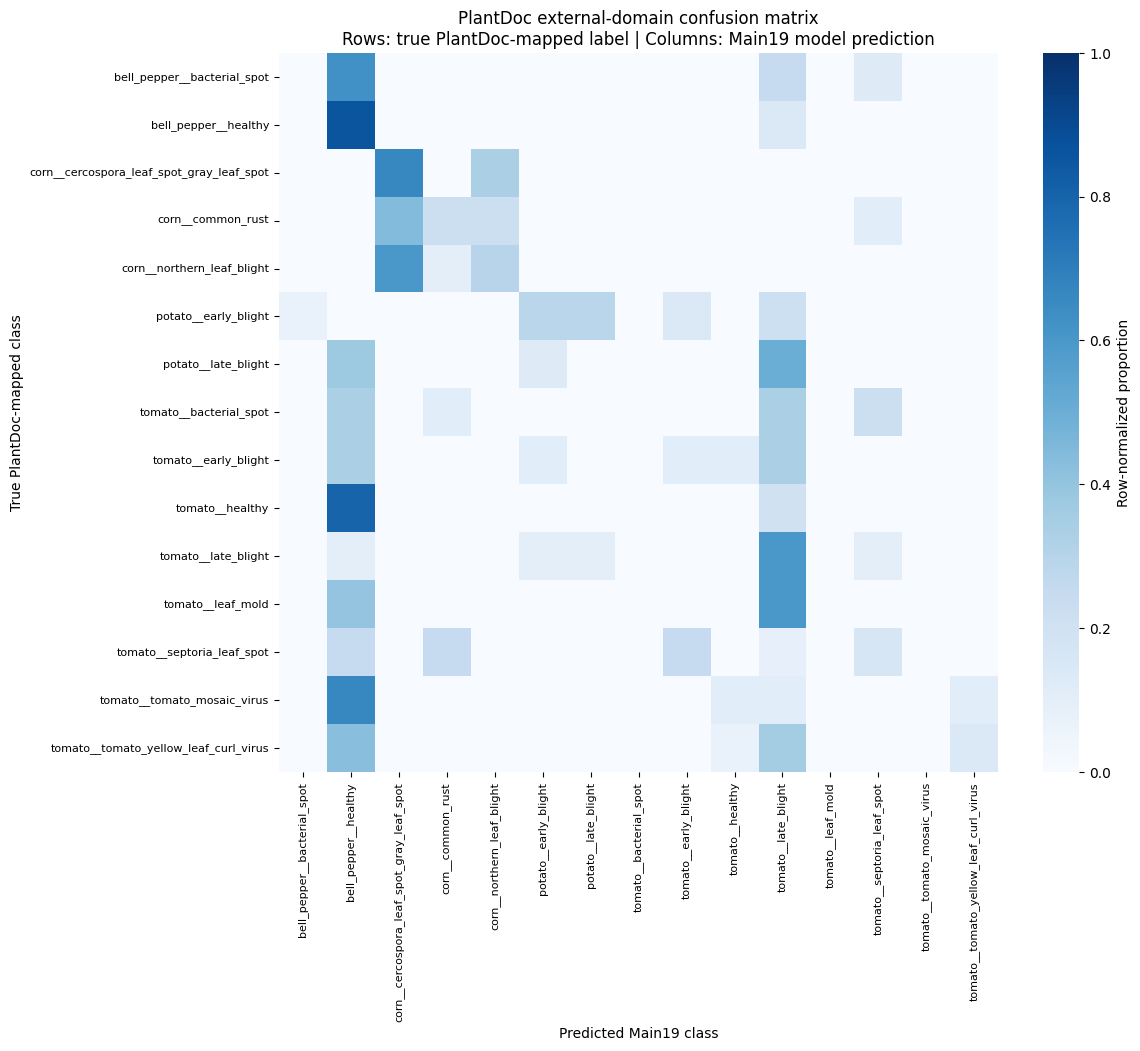

In [17]:
normalized_confusion_matrix = confusion_matrix(
    y_true,
    y_pred,
    labels=evaluated_indices,
    normalize="true",
)

matrix_size = max(
    12,
    len(evaluated_labels) * 0.62,
)

plt.figure(
    figsize=(
        matrix_size,
        matrix_size * 0.85,
    )
)

sns.heatmap(
    normalized_confusion_matrix,
    cmap="Blues",
    xticklabels=evaluated_labels,
    yticklabels=evaluated_labels,
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={
        "label": "Row-normalized proportion"
    },
)

plt.title(
    "PlantDoc external-domain confusion matrix\n"
    "Rows: true PlantDoc-mapped label | "
    "Columns: Main19 model prediction"
)

plt.xlabel("Predicted Main19 class")
plt.ylabel("True PlantDoc-mapped class")

plt.xticks(
    rotation=90,
    fontsize=8,
)

plt.yticks(
    rotation=0,
    fontsize=8,
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "fig_01_external_domain_confusion_matrix.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

,prediction_status,images,mean_confidence,median_confidence,accuracy
0,Correct,28,0.883024,0.976107,1.0
1,Incorrect,116,0.835847,0.917843,0.0


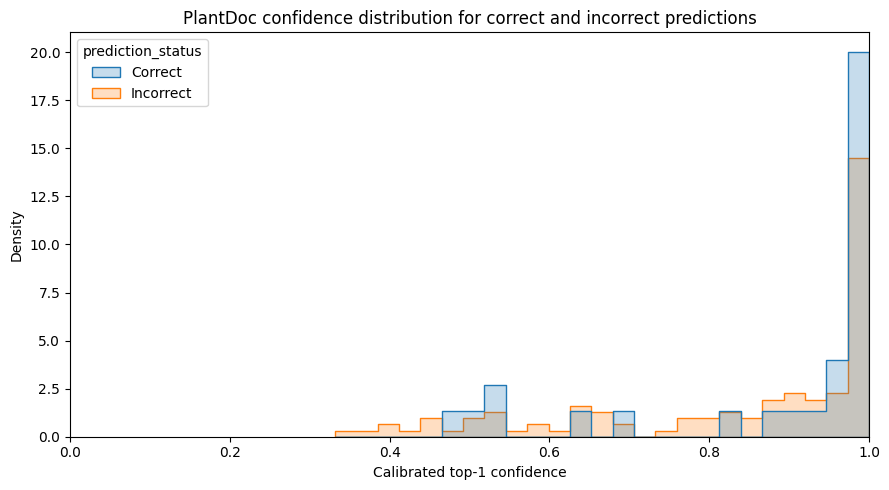

In [18]:
confidence_df = valid_predictions_df.copy()

confidence_df["prediction_status"] = np.where(
    confidence_df["correct_top1"] == 1,
    "Correct",
    "Incorrect",
)

confidence_summary = (
    confidence_df
    .groupby(
        "prediction_status",
        as_index=False,
    )
    .agg(
        images=("image_path", "count"),
        mean_confidence=("confidence", "mean"),
        median_confidence=("confidence", "median"),
        accuracy=("correct_top1", "mean"),
    )
)

display(confidence_summary)

confidence_summary.to_csv(
    RESULTS_DIR / "table_07_confidence_by_correctness.csv",
    index=False,
)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=confidence_df,
    x="confidence",
    hue="prediction_status",
    bins=25,
    stat="density",
    common_norm=False,
    element="step",
)

plt.title(
    "PlantDoc confidence distribution for correct "
    "and incorrect predictions"
)

plt.xlabel("Calibrated top-1 confidence")
plt.ylabel("Density")
plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "fig_02_confidence_correct_vs_incorrect.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

,confidence_threshold,retained_images,coverage,selective_accuracy,selective_macro_f1
0,0.00,144,1.000000,0.194444,0.142796
1,0.05,144,1.000000,0.194444,0.142796
2,0.10,144,1.000000,0.194444,0.142796
3,0.15,144,1.000000,0.194444,0.142796
4,0.20,144,1.000000,0.194444,0.142796
5,0.25,144,1.000000,0.194444,0.142796
6,0.30,144,1.000000,0.194444,0.142796
7,0.35,143,0.993056,0.195804,0.144581
8,0.40,140,0.972222,0.200000,0.149875
9,0.45,138,0.958333,0.202899,0.151799


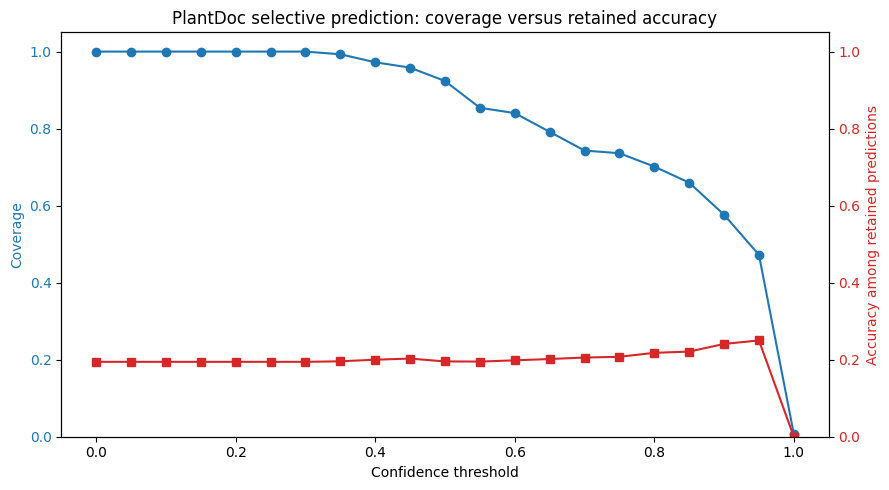

In [19]:
confidence_thresholds = np.round(
    np.arange(0.00, 1.01, 0.05),
    2,
)

selective_prediction_rows = []

for threshold in confidence_thresholds:
    retained_df = valid_predictions_df.loc[
        valid_predictions_df["confidence"] >= threshold
    ].copy()

    retained_images = len(retained_df)

    coverage = (
        retained_images
        / len(valid_predictions_df)
    )

    if retained_images > 0:
        retained_accuracy = retained_df[
            "correct_top1"
        ].mean()

    else:
        retained_accuracy = np.nan

    if retained_df["true_index"].nunique() > 1:
        retained_macro_f1 = f1_score(
            retained_df["true_index"],
            retained_df["predicted_index"],
            average="macro",
            zero_division=0,
        )

    else:
        retained_macro_f1 = np.nan

    selective_prediction_rows.append(
        {
            "confidence_threshold": threshold,
            "retained_images": retained_images,
            "coverage": coverage,
            "selective_accuracy": retained_accuracy,
            "selective_macro_f1": retained_macro_f1,
        }
    )

selective_prediction_df = pd.DataFrame(
    selective_prediction_rows
)

display(selective_prediction_df)

selective_prediction_df.to_csv(
    RESULTS_DIR
    / "table_08_selective_prediction_thresholds.csv",
    index=False,
)

figure, coverage_axis = plt.subplots(
    figsize=(9, 5)
)

coverage_axis.plot(
    selective_prediction_df[
        "confidence_threshold"
    ],
    selective_prediction_df["coverage"],
    marker="o",
    color="#1f77b4",
    label="Coverage",
)

coverage_axis.set_xlabel(
    "Confidence threshold"
)

coverage_axis.set_ylabel(
    "Coverage",
    color="#1f77b4",
)

coverage_axis.tick_params(
    axis="y",
    labelcolor="#1f77b4",
)

coverage_axis.set_ylim(0, 1.05)

accuracy_axis = coverage_axis.twinx()

accuracy_axis.plot(
    selective_prediction_df[
        "confidence_threshold"
    ],
    selective_prediction_df[
        "selective_accuracy"
    ],
    marker="s",
    color="#d62728",
    label="Selective accuracy",
)

accuracy_axis.set_ylabel(
    "Accuracy among retained predictions",
    color="#d62728",
)

accuracy_axis.tick_params(
    axis="y",
    labelcolor="#d62728",
)

accuracy_axis.set_ylim(0, 1.05)

plt.title(
    "PlantDoc selective prediction: "
    "coverage versus retained accuracy"
)

figure.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "fig_03_selective_prediction_curve.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

,crop,images,classes,top1_accuracy,mean_confidence,median_confidence
0,tomato,79,8,0.139241,0.821302,0.894776
1,potato,22,2,0.181818,0.851697,0.946036
2,corn,26,3,0.269231,0.895575,0.992198
3,bell_pepper,17,2,0.352941,0.869282,0.959754


/tmp/ipykernel_23/2317996339.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


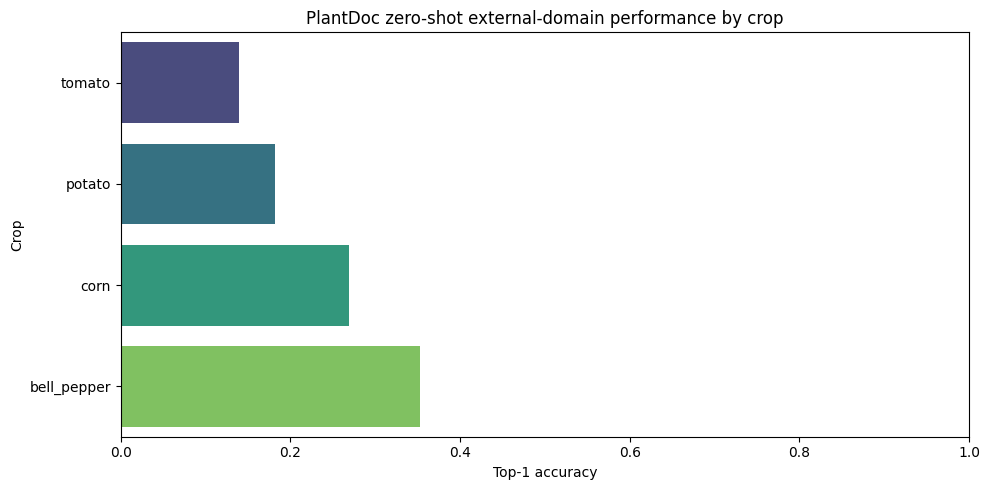

In [20]:
crop_metrics = (
    valid_predictions_df
    .groupby(
        "crop",
        as_index=False,
    )
    .agg(
        images=("image_path", "count"),
        classes=("true_label", "nunique"),
        top1_accuracy=("correct_top1", "mean"),
        mean_confidence=("confidence", "mean"),
        median_confidence=("confidence", "median"),
    )
    .sort_values(
        "top1_accuracy",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(crop_metrics)

crop_metrics.to_csv(
    RESULTS_DIR
    / "table_09_external_crop_metrics.csv",
    index=False,
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=crop_metrics,
    x="top1_accuracy",
    y="crop",
    palette="viridis",
)

plt.xlim(0, 1)
plt.xlabel("Top-1 accuracy")
plt.ylabel("Crop")
plt.title(
    "PlantDoc zero-shot external-domain performance by crop"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "fig_04_external_accuracy_by_crop.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

In [21]:
high_confidence_errors = (
    valid_predictions_df
    .loc[
        valid_predictions_df["correct_top1"] == 0
    ]
    .sort_values(
        "confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Incorrect external predictions:",
    len(high_confidence_errors),
)

display(
    high_confidence_errors[
        [
            "image_path",
            "plantdoc_folder",
            "true_label",
            "predicted_label",
            "confidence",
            "top5_labels",
            "top5_probabilities",
        ]
    ].head(30)
)

high_confidence_errors.to_csv(
    RESULTS_DIR
    / "table_10_high_confidence_external_errors.csv",
    index=False,
)

Incorrect external predictions: 116


,image_path,plantdoc_folder,true_label,predicted_label,confidence,top5_labels,top5_probabilities
0,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Potato_leaf_late_blight/test_Potato leaf late blight_2.jpg,Potato_leaf_late_blight,potato__late_blight,tomato__late_blight,1.000000,"[""tomato__late_blight"", ""tomato__septoria_leaf_spot"", ""corn__healthy"", ""potato__late_blight"", ""tomato__leaf_mold""]","[1.0, 4.597937675043795e-08, 1.5032174616180782e-08, 3.682689930784022e-09, 3.5530292041840994e-09]"
1,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Corn_leaf_blight/test_Corn leaf blight_5.jpg,Corn_leaf_blight,corn__northern_leaf_blight,corn__cercospora_leaf_spot_gray_leaf_spot,1.000000,"[""corn__cercospora_leaf_spot_gray_leaf_spot"", ""corn__common_rust"", ""tomato__healthy"", ""bell_pepper__healthy"", ""tomat...","[0.9999998807907104, 1.0242867887200191e-07, 3.1969666025588594e-08, 1.0178846210351367e-08, 3.761237987731647e-09]"
2,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Potato_leaf_late_blight/test_Potato leaf late blight_7.jpg,Potato_leaf_late_blight,potato__late_blight,tomato__late_blight,0.999999,"[""tomato__late_blight"", ""tomato__septoria_leaf_spot"", ""bell_pepper__healthy"", ""potato__late_blight"", ""bell_pepper__b...","[0.9999990463256836, 5.584632845057058e-07, 1.959396058737184e-07, 1.486065031031103e-07, 2.5286968075022287e-09]"
3,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Tomato_mold_leaf/test_Tomato mold leaf_3.jpg,Tomato_mold_leaf,tomato__leaf_mold,tomato__late_blight,0.999998,"[""tomato__late_blight"", ""tomato__early_blight"", ""tomato__septoria_leaf_spot"", ""potato__late_blight"", ""bell_pepper__h...","[0.9999977350234985, 2.173212351408438e-06, 3.891291555646603e-08, 2.056838077635348e-08, 1.5469103331611223e-08]"
4,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Corn_rust_leaf/test_Corn rust leaf_7.jpg,Corn_rust_leaf,corn__common_rust,corn__cercospora_leaf_spot_gray_leaf_spot,0.999995,"[""corn__cercospora_leaf_spot_gray_leaf_spot"", ""tomato__healthy"", ""corn__northern_leaf_blight"", ""corn__common_rust"", ...","[0.9999953508377075, 1.7817034176914603e-06, 1.7140357613243395e-06, 2.0461068572785734e-07, 1.9519565341852285e-07]"
5,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Potato_leaf_late_blight/test_Potato leaf late blight_5.jpg,Potato_leaf_late_blight,potato__late_blight,potato__early_blight,0.999995,"[""potato__early_blight"", ""potato__late_blight"", ""tomato__late_blight"", ""tomato__early_blight"", ""corn__northern_leaf_...","[0.9999949932098389, 4.3792888391180895e-06, 6.67392839659442e-07, 4.1988439392071086e-08, 3.785818325496848e-10]"
6,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Tomato_leaf_yellow_virus/test_Tomato leaf yellow virus_...,Tomato_leaf_yellow_virus,tomato__tomato_yellow_leaf_curl_virus,tomato__late_blight,0.999993,"[""tomato__late_blight"", ""bell_pepper__healthy"", ""corn__healthy"", ""tomato__early_blight"", ""tomato__leaf_mold""]","[0.9999927282333374, 3.2093985282699578e-06, 3.108997816525516e-06, 5.299460781316156e-07, 3.157136632125912e-07]"
7,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Bell_pepper_leaf_spot/test_Bell_pepper leaf spot_8.jpg,Bell_pepper_leaf_spot,bell_pepper__bacterial_spot,tomato__late_blight,0.999982,"[""tomato__late_blight"", ""tomato__early_blight"", ""bell_pepper__healthy"", ""corn__common_rust"", ""tomato__healthy""]","[0.9999822378158569, 1.0209412721451372e-05, 7.333310804824578e-06, 1.1277501243966981e-07, 1.0296586694380494e-08]"
8,/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Corn_Gray_leaf_spot/test_Corn Gray leaf spot_4.jpg,Corn_Gray_leaf_spot,corn__cercospora_leaf_spot_gray_leaf_spot,corn__healthy,0.999977,"[""corn__healthy"", ""corn__northern_leaf_blight"", ""corn__cercospora_leaf_spot_gray_leaf_spot"", ""tomato__late_blight"", ...","[0.9999774694442749, 8.225757483160123e-06, 3.31012006427045e-06,

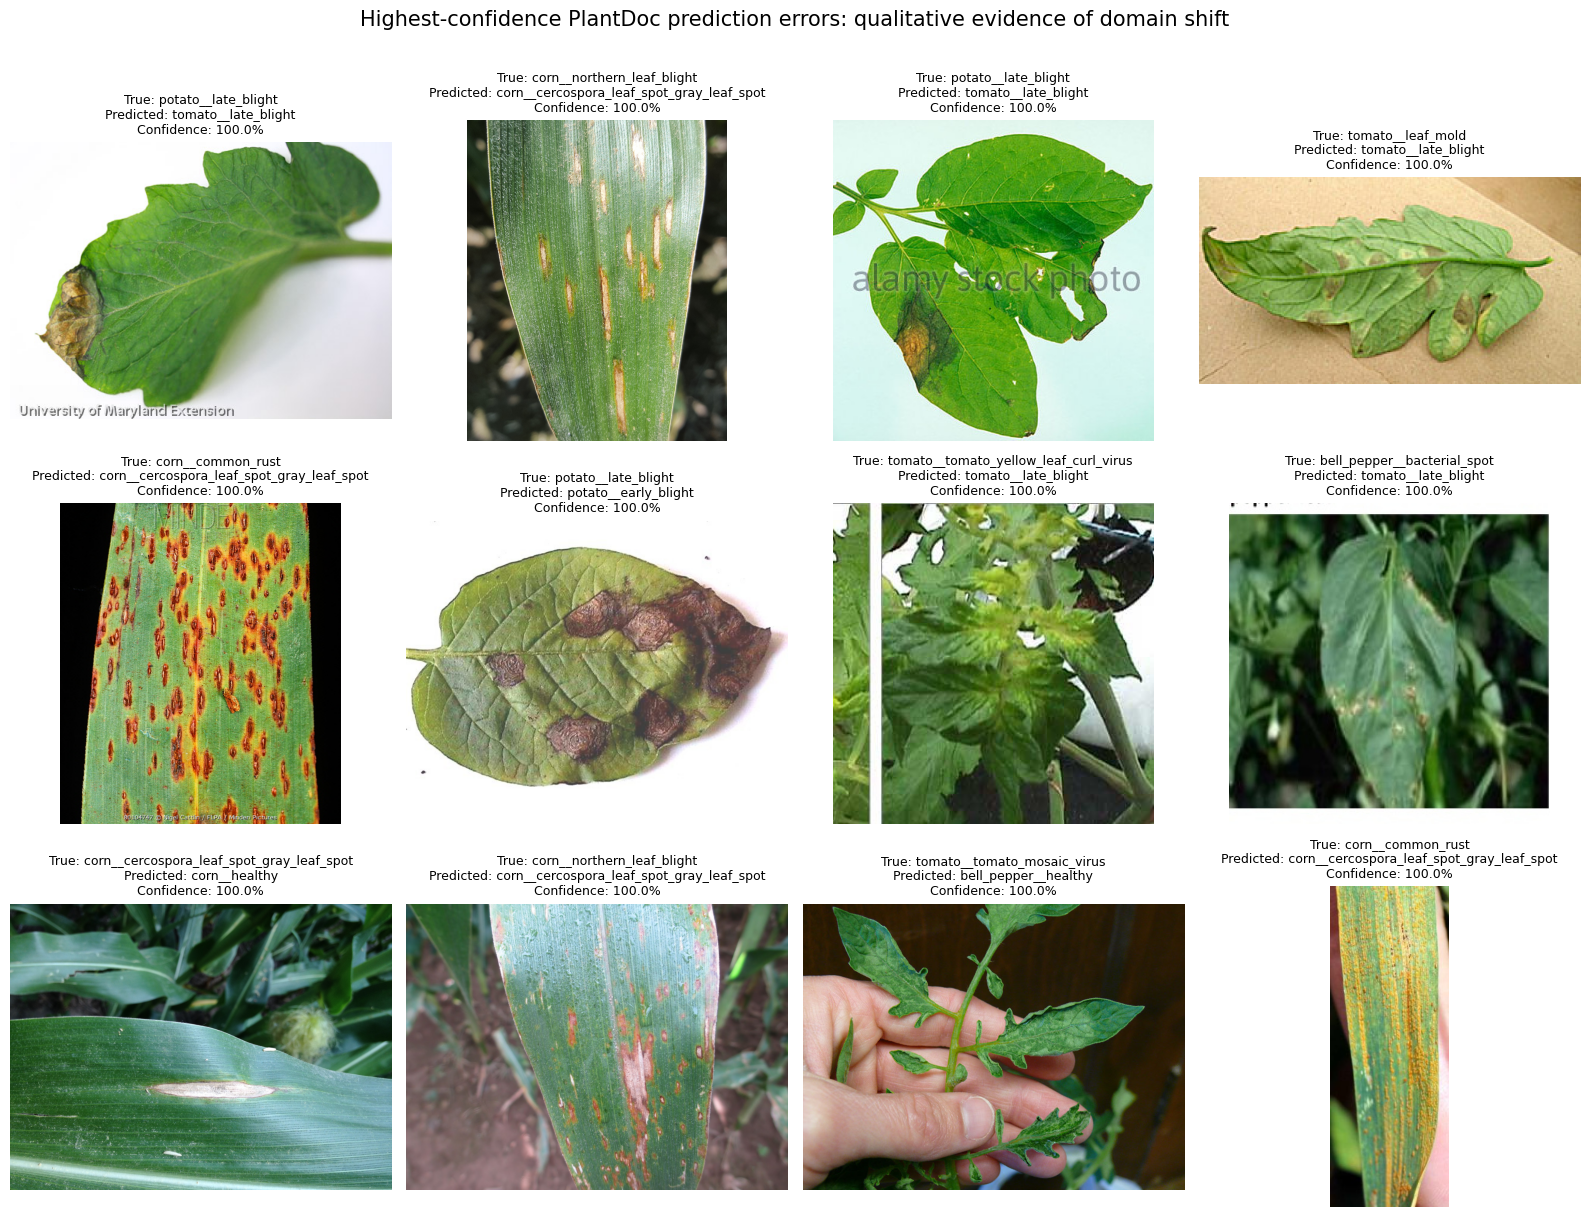

In [22]:
def show_prediction_grid(
    dataframe,
    n=12,
    title="PlantDoc external prediction inspection",
):
    subset = dataframe.head(n).copy()

    if subset.empty:
        print("No images are available.")
        return

    number_of_columns = 4
    number_of_rows = int(
        np.ceil(
            len(subset)
            / number_of_columns
        )
    )

    figure, axes = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(
            16,
            4 * number_of_rows,
        ),
    )

    axes = np.asarray(axes).reshape(-1)

    for axis, (_, row) in zip(
        axes,
        subset.iterrows(),
    ):
        try:
            image = Image.open(
                row["image_path"]
            ).convert("RGB")

            axis.imshow(image)

        except Exception:
            axis.text(
                0.5,
                0.5,
                "Could not load image",
                horizontalalignment="center",
                verticalalignment="center",
            )

        axis.set_title(
            f"True: {row['true_label']}\n"
            f"Predicted: {row['predicted_label']}\n"
            f"Confidence: {row['confidence']:.1%}",
            fontsize=9,
        )

        axis.axis("off")

    for axis in axes[len(subset):]:
        axis.axis("off")

    figure.suptitle(
        title,
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()

show_prediction_grid(
    dataframe=high_confidence_errors,
    n=12,
    title=(
        "Highest-confidence PlantDoc prediction errors: "
        "qualitative evidence of domain shift"
    ),
)

In [23]:
run_metadata = {
    "notebook": (
        "10_external_domain_shift_plantdoc"
    ),
    "evaluation_protocol": (
        "Zero-shot external evaluation using PlantDoc test only"
    ),
    "model": "EfficientNet-B0 Main19",
    "checkpoint_path": str(CHECKPOINT_PATH),
    "class_mapping_path": str(CLASS_MAPPING_PATH),
    "index_mapping_path": (
        str(INDEX_MAPPING_PATH)
        if INDEX_MAPPING_PATH is not None
        else None
    ),
    "plantdoc_root": str(PLANTDOC_ROOT),
    "plantdoc_test_root": str(EVAL_ROOT),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "device": str(DEVICE),
    "temperature": float(temperature),
    "temperature_source": temperature_source,
    "test_images_in_manifest": int(
        len(predictions_df)
    ),
    "valid_test_images_evaluated": int(
        len(valid_predictions_df)
    ),
    "compatible_main19_classes": int(
        valid_predictions_df["true_label"].nunique()
    ),
    "top1_accuracy": float(
        overall_metrics.loc[
            0,
            "top1_accuracy",
        ]
    ),
    "balanced_accuracy": float(
        overall_metrics.loc[
            0,
            "balanced_accuracy",
        ]
    ),
    "macro_f1": float(
        overall_metrics.loc[
            0,
            "macro_f1",
        ]
    ),
    "weighted_f1": float(
        overall_metrics.loc[
            0,
            "weighted_f1",
        ]
    ),
    "top5_accuracy": float(
        overall_metrics.loc[
            0,
            "top5_accuracy",
        ]
    ),
    "excluded_plantdoc_folders": (
        excluded_mapping["plantdoc_folder"]
        .tolist()
    ),
    "notes": (
        "PlantDoc train images were not used. "
        "Supervised metrics include only semantically compatible "
        "classes present in the Main19 label mapping. "
        "The experiment measures external domain shift."
    ),
}

metadata_path = (
    RESULTS_DIR
    / "run_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        run_metadata,
        file,
        indent=2,
    )

print(
    json.dumps(
        run_metadata,
        indent=2,
    )
)

{
  "notebook": "10_external_domain_shift_plantdoc",
  "evaluation_protocol": "Zero-shot external evaluation using PlantDoc test only",
  "model": "EfficientNet-B0 Main19",
  "checkpoint_path": "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/best_efficientnet_b0_main19.pt",
  "class_mapping_path": "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/class_to_index_main19.json",
  "index_mapping_path": "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/index_to_class_main19.json",
  "plantdoc_root": "/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset",
  "plantdoc_test_root": "/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test",
  "image_size": 224,
  "batch_size": 32,
  "device": "cuda",
  "temperature": 1.0,
  "temperature_source": "default_unscaled_softmax",
  "test_images_in_manifest": 144,
  "valid_test_images_evaluated": 144,
  "compatible_main19_clas

## Interpretation

This notebook performs a zero-shot external-domain evaluation:

- The EfficientNet-B0 model was trained on the Main19 PlantVillage subset.
- PlantDoc test images were not used for training, validation, checkpoint selection, temperature fitting, or threshold selection.
- Only semantically compatible classes from the project’s Main19 label space were evaluated.

### Report these outputs

1. Number of compatible PlantDoc images and classes.
2. Top-1 accuracy, balanced accuracy, macro F1, weighted F1, and top-5 accuracy.
3. Per-class recall and F1 score.
4. External-domain confusion matrix.
5. Confidence distribution for correct and incorrect predictions.
6. Selective-prediction coverage versus retained accuracy.
7. High-confidence incorrect predictions and visual explanations.

### Recommended report wording

> “The final EfficientNet-B0 Main19 classifier was evaluated zero-shot on the PlantDoc test split using only semantically compatible crop–disease labels. Performance was lower than controlled PlantVillage performance, demonstrating external domain shift associated with natural backgrounds, illumination changes, occlusion, multiple leaves, framing variability, and symptom-appearance variation. Confidence-based selective prediction can improve reliability among retained predictions, but it does not eliminate domain-shift risk.”